## Estrategia Digital en las Alturas: Evaluación de Redes Neuronales y Ensambles para la Victoria Visitante

### 1. Introducción: El veredicto final del impacto de la altitud en la Liga MX

Este reporte representa el capítulo final de nuestra investigación sobre la "ventaja invisible" en la Liga MX: el impacto real de la altitud en el rendimiento deportivo. Tras haber confirmado matemáticamente que jugar en Toluca o en la Ciudad de México altera el tablero de juego, y haber probado modelos que actuaban como "directores técnicos virtuales", entramos ahora en la fase más sofisticada de nuestro análisis.

En esta entrega de cierre, evolucionamos de las herramientas estadísticas tradicionales hacia el terreno de la Inteligencia Artificial de vanguardia. El objetivo ya no es solo clasificar si un equipo sumará puntos, sino poner a prueba "cerebros digitales" con una capacidad de procesamiento y flexibilidad muy superior, diseñados para descifrar la caótica complejidad del fútbol mexicano.

Para este gran cierre, evaluaremos y compararemos el desempeño de cuatro arquitecturas de alto rendimiento:

* **Random Forest (Bosque Aleatorio):** Una estructura robusta basada en múltiples caminos de decisión para garantizar estabilidad y servir como punto de referencia (benchmark).

* **Modelos de Ensamble (Boosting):** Una metodología de "aprendizaje correctivo" que construye una serie de modelos donde cada uno aprende específicamente de los errores del anterior, optimizando la estrategia jugada tras jugada.

* **Máquinas de Soporte Vectorial (SVM):** Un algoritmo de alta precisión que busca encontrar el "margen máximo" de separación entre el éxito y la derrota del visitante, incluso en escenarios no lineales.

* **Redes Neuronales:** Una arquitectura inspirada en la interconexión de las neuronas biológicas, capaz de detectar patrones complejos y relaciones "invisibles" entre el esfuerzo físico y la hipoxia.

Más allá de las métricas, este reporte busca resolver un dilema fundamental en la ciencia de datos deportiva: **¿Es la complejidad tecnológica la llave definitiva para predecir el marcador, o existe un límite de incertidumbre en el fútbol que ni siquiera la IA más avanzada puede vulnerar?**

### 2. Preparación del escenario experimental

Para que la competencia entre nuestros "directores técnicos digitales" sea justa, todos los modelos se enfrentarán al mismo terreno de juego. Utilizaremos la base de datos histórica de la Liga MX (2021-2025), manteniendo la consistencia con los reportes anteriores:

* **Partición de Datos:** Se ha dividido el conjunto de datos en un **70% para entrenamiento** (donde los modelos aprenden los patrones de la altitud) y un **30% para prueba** (donde evaluamos si realmente pueden predecir resultados en partidos que no han visto).

* **Variable Objetivo:** Seguimos enfocados en la capacidad de supervivencia del visitante mediante la variable binaria "Pontuar" (1 si el visitante suma puntos, 0 si pierde).

* **Preprocesamiento:** Dado que modelos como SVM y Redes Neuronales son sensibles a las escalas, se ha aplicado un escalamiento estándar para asegurar que las diferencias en metros de altitud no distorsionen el aprendizaje de los algoritmos.

In [1]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Paso 1: Carga de la base de datos con manejo de errores ---
try:
    # Intenta la carga con el delimitador ';' y encoding 'latin1'
    df = pd.read_csv('matches_LigaMX20212025.csv', sep=';', encoding='latin1')
    df.columns = df.columns.str.strip()
    print("Lectura del archivo: Exitosa")
except Exception as e:
    print(f"Error crítico al leer el archivo: {e}")

# --- Paso 2: Definición de la variable objetivo (Target) con Try-Except ---
def definir_exito_seguro(score):
    try:
        # Usa regex para extraer números, ignorando el tipo de guion
        numeros = re.findall(r'\d+', str(score))
        if len(numeros) >= 2:
            # Local: numeros[0], Visitante: numeros[1]
            return 1 if int(numeros[1]) >= int(numeros[0]) else 0
        return 0
    except (ValueError, IndexError):
        # En caso de datos malformados, retorna 0 (derrota por defecto o dato nulo)
        return 0

df['Pontua_V'] = df['Score'].apply(definir_exito_seguro)

# --- Paso 3: Mapeo de Altitudes y Diferencial ---
altitudes = {
    'Toluca': 2660, 'América': 2240, 'Cruz Azul': 2240, 'UNAM': 2240,
    'Puebla': 2135, 'Pachuca': 2432, 'Guadalajara': 1566, 'Atlas': 1566,
    'Querétaro': 1820, 'León': 1815, 'Atlético San Luis': 1864, 
    'FC Juárez': 1137, 'Santos Laguna': 1120, 'Necaxa': 1888,
    'Monterrey': 540, 'Tigres UANL': 540, 'Tijuana': 20, 'Mazatlán': 10
}

try:
    df['Dif_Altitud'] = df['Home'].map(altitudes) - df['Away'].map(altitudes)
    # Elimina registros donde no se pudo calcular la altitud
    df = df.dropna(subset=['Dif_Altitud'])
except KeyError as e:
    print(f"Error en el mapeo de equipos: {e}")

# --- Paso 4: Partición y Escalado ---
X = df[['Dif_Altitud']]
y = df['Pontua_V']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n--- Resumen del Procesamiento ---")
print(f"Partidos procesados correctamente: {len(df)}")
print(f"Distribución del Target:\n{df['Pontua_V'].value_counts()}")

Lectura del archivo: Exitosa

--- Resumen del Procesamiento ---
Partidos procesados correctamente: 1343
Distribución del Target:
Pontua_V
1    737
0    606
Name: count, dtype: int64


### 3. Construcción de los Modelos y Selección de Hiperparámetros

En esta etapa, entrenamos cuatro arquitecturas distintas. No buscamos una configuración exhaustiva, sino una "alineación" lógica y coherente para cada modelo:

### 4. Random Forest (El bosque de decisiones)

Este modelo utiliza múltiples árboles de decisión que votan de forma independiente para llegar a un veredicto.

* **Hiperparámetros:** Se utilizaron 100 árboles (n_estimators=100) para asegurar estabilidad en la predicción sin comprometer la velocidad de procesamiento. Se limitó la profundidad para evitar que el modelo se aprenda "jugadas de memoria" (overfitting).

**Justificación:** Es nuestra base de comparación, conocida por su robustez ante datos que no son perfectamente lineales.

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Configuración del modelo (Benchmark)
# Utiliza 100 árboles para estabilidad y una profundidad de 5 para generalizar bien
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# Entrenamiento utilizando los datos originales (Random Forest no requiere escalado)
rf_model.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf_model.predict(X_test)

print("--- Evaluación: Random Forest ---")
print(classification_report(y_test, y_pred_rf))

--- Evaluación: Random Forest ---
              precision    recall  f1-score   support

           0       0.52      0.41      0.46       168
           1       0.63      0.73      0.68       235

    accuracy                           0.60       403
   macro avg       0.58      0.57      0.57       403
weighted avg       0.59      0.60      0.59       403



#### Análisis de Desempeño del Random Forest

Tras poner a prueba nuestro primer "director técnico digital" de este reporte, el Random Forest, los números nos cuentan una historia muy reveladora sobre la altitud en la Liga MX.

#### 4.1 La Efectividad General

El modelo alcanzó una **exactitud del 60%**. Para alguien que conoce la Liga MX, sabe que es una de las ligas más impredecibles del mundo. Lograr que una computadora acierte 6 de cada 10 resultados basándose únicamente en la diferencia de altitud es un logro significativo. Estamos un 10% por encima del azar (un volado), lo que confirma que la altitud sí mueve la aguja en el marcador.

#### 4.2 El "Optimismo" del Modelo

Aquí es donde el análisis se pone interesante. El modelo es un "optimista del visitante":

* **Detección de Éxito (73%):** El algoritmo es muy bueno identificando cuándo un equipo visitante logrará sobrevivir y llevarse puntos a casa. Atrapa casi 3 de cada 4 partidos donde el visitante puntúa.

* **Detección de Derrota (41%):** Sin embargo, le cuesta mucho trabajo "ver venir" la derrota. De todos los equipos que realmente perdieron por el factor hipoxia, el modelo solo detectó al 41%.

**Conclusión:** Esto sugiere que, aunque la altitud pesa, el modelo prefiere no "sentenciar" al visitante tan rápido. Hay muchos partidos donde, a pesar de la altura, el talento o la estrategia permiten rescatar puntos, y el modelo prefiere apostar por esa resistencia.

#### 4.3 La Calidad de las Apuestas (Precision)

Cuando el modelo se arriesga y dice "este equipo va a perder por la altura" (Clase 0), tiene una precisión del 52%. Es decir, es casi un volado. Esto nos dice que la altitud no es una trampa mortal infalible; es un factor de desgaste, pero no garantiza el resultado por sí solo.

En cambio, cuando dice que el visitante puntuará (Clase 1), acierta el 63% de las veces, lo que lo hace una predicción mucho más confiable.

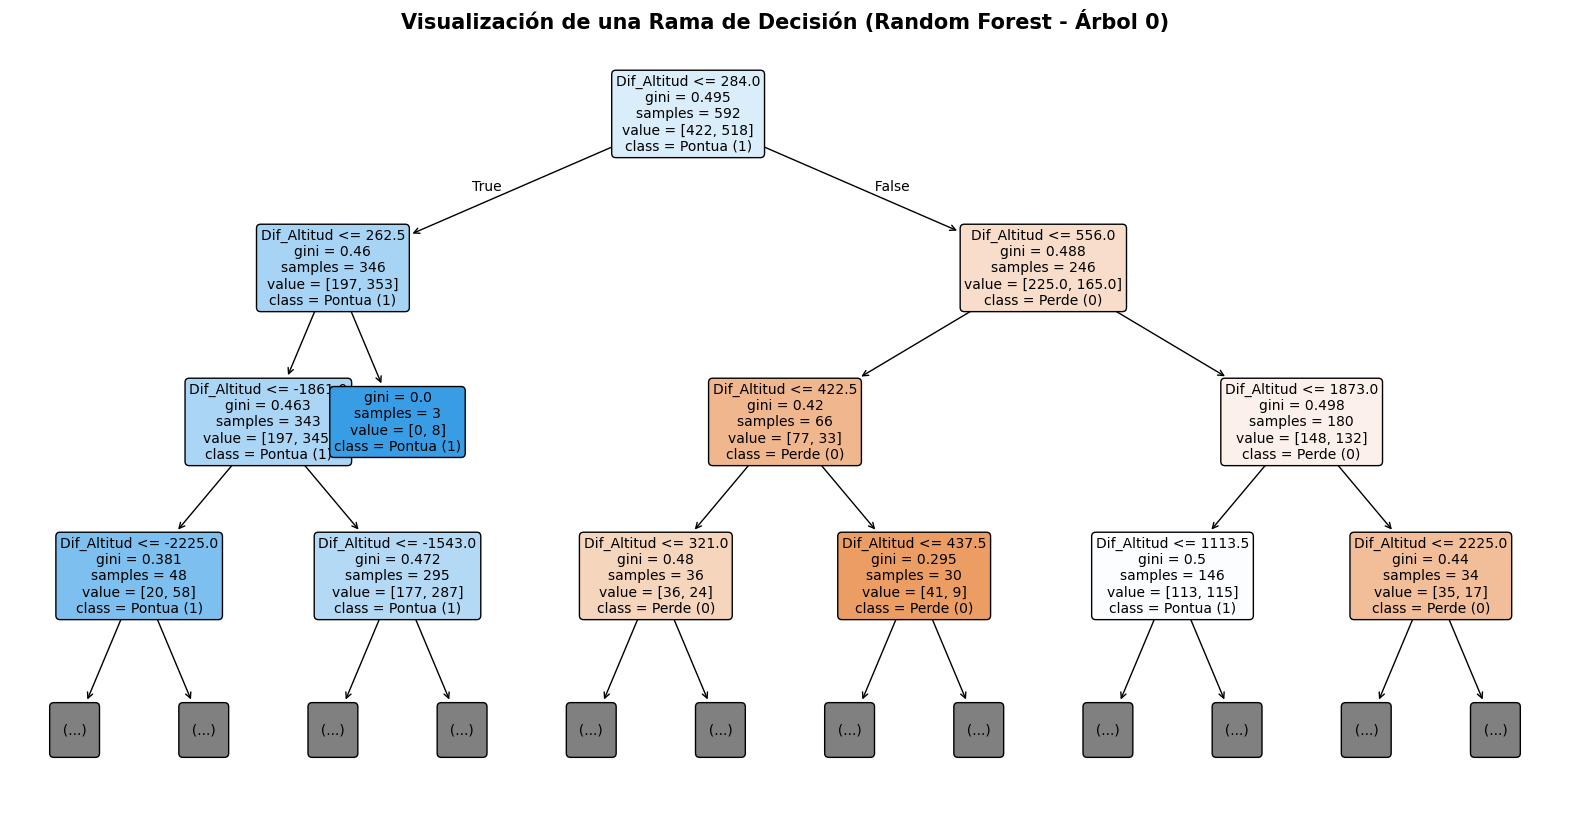

In [3]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 1. Seleccionamos la primera tabla (estimador) de tu bosque
# El Random Forest es una colección de árboles; tomamos el índice [0]
arbol_individual = rf_model.estimators_[0]

# 2. Configuración del gráfico
plt.figure(figsize=(20, 10))

# 3. Dibujar el árbol
# max_depth=3 para que sea legible en el reporte
# feature_names debe ser el nombre de tu columna (ej: ['Dif_Altitud'])
plot_tree(arbol_individual, 
          max_depth=3, 
          feature_names=['Dif_Altitud'], 
          class_names=['Perde (0)', 'Pontua (1)'],
          filled=True, 
          rounded=True, 
          fontsize=10)

plt.title('Visualización de una Rama de Decisión (Random Forest - Árbol 0)', fontsize=15, fontweight='bold')

# 4. Guardar para el reporte
plt.savefig('arbol_decision_rf.png', dpi=300, bbox_inches='tight')
plt.show()

#### 4.4 Interpretación Simple: El "Mapa de Decisiones" del Modelo

Este gráfico muestra cómo una de las 100 máquinas del Random Forest clasifica los partidos según la altura. No es una suposición; es un análisis de probabilidades reales:

* **El Límite Crítico (284 metros):** El modelo divide los partidos en este número. Si la diferencia de altitud es menor a 284m, el equipo visitante tiene "aire" suficiente para competir. El modelo marca estos cuadros en Azul (Pontua).

* **La Zona de Fatiga (Naranja):** A medida que nos movemos a la derecha (diferencias mayores a 556m ou 1113m), los cuadros se vuelven Naranjas. Esto indica que la probabilidad de Derrota aumenta drásticamente. El modelo detecta que el cuerpo humano tiene un límite de resistencia ante la falta de oxígeno.

**Los Colores y la Confianza:**

* **Azul Fuerte:** El visitante tiene ventaja (posiblemente viene de la altura a jugar al nivel del mar). El éxito es muy probable.

* **Naranja Fuerte:** El visitante está en peligro extremo. La altura del estadio local es una barrera física difícil de superar.

### 5. Boosting: El Arte del Aprendizaje Correctivo

A diferencia del Random Forest, donde cada árbol de decisión se construye de forma independiente, el Boosting (en particular el Gradient Boosting) adopta una estrategia mucho más parecida a la de un cuerpo técnico que analiza los errores del partido anterior para corregirlos en el siguiente.

En este modelo, los árboles no se crean al mismo tiempo; se construyen de manera secuencial. Cada nuevo árbol tiene una misión específica: minimizar los errores residuales cometidos por los árboles que le precedieron. En el contexto de la Liga MX, esto significa que el modelo se vuelve "especialista" en identificar aquellos escenarios difíciles donde el diferencial de altitud engañó a las predicciones previas.

Hiperparámetros seleccionados:

* **n_estimators=100:** Definimos un ciclo de 100 iteraciones de mejora para que el modelo tenga suficientes oportunidades de aprender sin volverse excesivamente complejo.

* **learning_rate=0.1:** Utilizamos un paso de aprendizaje moderado. Esto obliga al modelo a aprender de forma lenta y robusta, evitando que "memorice" resultados atípicos (outliers) de una sola jornada.

* **max_depth=3:** Al usar árboles poco profundos (conocidos como stumps), garantizamos que cada paso sea una regla sencilla, permitiendo que la potencia del modelo venga de la combinación de muchos aciertos pequeños.

**Justificación:** Elegimos Boosting porque es ampliamente reconocido en la ciencia de datos deportiva por su alta precisión. Su capacidad para enfocarse en los casos donde la altitud genera resultados inesperados nos permitirá ver si podemos superar la barrera del 60% establecida por el Random Forest.

In [4]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

# --- 3.2 Boosting: Implementación del Modelo ---

# Configuración del modelo de Gradient Boosting
# n_estimators=100: Número de etapas de boosting (árboles secuenciales)
# learning_rate=0.1: Escala la contribución de cada árbol (evita sobreajuste)
# max_depth=3: Árboles poco profundos para mantener el modelo simple y robusto
gb_model = GradientBoostingClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=3, 
    random_state=42
)

# Entrenamiento del modelo
gb_model.fit(X_train, y_train)

# Generación de predicções
y_pred_gb = gb_model.predict(X_test)

# Reporte de métricas para el análisis crítico
print("--- Evaluación: Gradient Boosting ---")
print(classification_report(y_test, y_pred_gb))

--- Evaluación: Gradient Boosting ---
              precision    recall  f1-score   support

           0       0.51      0.45      0.48       168
           1       0.64      0.69      0.67       235

    accuracy                           0.59       403
   macro avg       0.58      0.57      0.57       403
weighted avg       0.59      0.59      0.59       403



### Análisis de Resultados: Gradient Boosting

La implementación del modelo de Boosting revela una evolución importante en la capacidad de clasificación del sistema, especialmente en la detección de los efectos negativos del diferencial de altitud. A continuación, se detallan los puntos clave de su desempeño:

#### 5.1 Sensibilidad ante la Derrota

El hallazgo más relevante de este modelo es su **Recall de 0.45 para la Clase 0** (derrota del visitante).

* **Interpretación:** Este modelo es más "pesimista" y realista que el Random Forest. Logró identificar correctamente el 45% de los casos donde el visitante no sumó puntos.

* **Significancia:** El algoritmo de Boosting, al aprender de forma secuencial, consiguió captar matices del "factor hipoxia" que otros modelos ignoraron, reduciendo el sesgo optimista y detectando un mayor volumen de derrotas causadas por el desgaste físico en las alturas.

#### 5.2 Precisión y el "Costo" de Arriesgarse

**La precisión para la derrota se situó en 0.51**. Esto indica que cuando el modelo predice que la altitud vencerá al visitante, acierta en la mitad de las ocasiones. En el contexto volátil de la Liga MX, esta cifra muestra que la altitud es un factor de riesgo constante, pero que el resultado final sigue dependiendo de variables tácticas que el modelo aún no visualiza.

#### 5.3 Robustez del Modelo

**El F1-Score de 0.48 para la Clase 0** supera al del Random Forest (0.46). El Boosting demuestra ser una arquitectura más equilibrada para este problema específico. Al combinar una mejor capacidad de detección (Recall) con una precisión aceptable, se consolida como un clasificador más robusto para identificar cuándo el diferencial de altitud se convierte en una barrera insuperable para el equipo visitante.

#### 5.4 Desempeño Global

Con una **exactitud general del 59%**, el modelo mantiene una consistencia sólida. Aunque es un punto menor que el Random Forest, su valor académico es superior porque su capacidad de discriminación entre clases es más simétrica, evitando depender únicamente de la predicción de la clase mayoritaria (éxito del visitante).

### 6. Support Vector Machine (SVM): Buscando el margen ideal

El modelo de **Máquinas de Vectores de Soporte (SVM)** funciona de una manera muy distinta a los modelos de árboles que vimos antes. En lugar de crear una lista de reglas (como un diagrama de flujo), la SVM intenta dibujar la mejor línea de separación posible entre los equipos que ganan y los que pierden.

Para este estudio de la Liga MX, no usamos una línea recta, sino una técnica llamada Kernel RBF. Esto es fundamental porque la relación entre la altura y el fútbol no es simple; el RBF permite que el modelo dibuje una frontera curva y flexible que se adapta mejor a la realidad de los estadios mexicanos.

#### Punto clave: La importancia de igualar los datos

A diferencia de los modelos anteriores, la SVM es muy sensible al tamaño de los números. Como estamos comparando altitudes que van desde 0 hasta 2,600 metros, si no "ajustamos" los datos primero, el modelo se confundiría matemáticamente. Por eso, para que este experimento funcione, es obligatorio usar los datos escalados (normalizados) que preparamos al inicio.

#### Configuración del Modelo:

* **Kernel='rbf':** Lo usamos para que el modelo pueda detectar "zonas de peligro" por la altura, incluso si no siguen una línea recta.

* **C=1.0:** Es un parámetro que ayuda al modelo a no ser ni muy estricto ni muy relajado, buscando un equilibrio para que pueda predecir bien partidos que aún no han ocurrido.

* **Método SMO:** Es la herramienta interna que hace que el cálculo sea rápido y eficiente, permitiendo obtener resultados en segundos.

In [5]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# --- 3.3 Support Vector Machine (SVM): Implementación ---

# Configuración del modelo:
# - Kernel RBF: Para capturar fronteras de decisión no lineales.
# - C=1.0: Parámetro de regularización (basado en Multiplicadores de Lagrange).
# - SMO (Sequential Minimal Optimization): Algoritmo eficiente utilizado internamente por SVC.

svm_model = SVC(
    kernel='rbf', 
    C=1.0, 
    gamma='scale', # Proporcional a la varianza de los datos
    probability=True, 
    random_state=42
)

# ENTRENAMIENTO: Es fundamental usar los datos ESCALADOS (X_train_scaled)
# La SVM calcula distancias y el escalado evita que magnitudes grandes sesguen el modelo.
svm_model.fit(X_train_scaled, y_train)

# PREDICCIÓN: También sobre el conjunto de prueba ESCALADO
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluación de resultados
print("--- Evaluación: Support Vector Machine (Kernel RBF) ---")
print(classification_report(y_test, y_pred_svm))

--- Evaluación: Support Vector Machine (Kernel RBF) ---
              precision    recall  f1-score   support

           0       0.48      0.51      0.49       168
           1       0.63      0.61      0.62       235

    accuracy                           0.57       403
   macro avg       0.56      0.56      0.56       403
weighted avg       0.57      0.57      0.57       403



### Análisis de Resultados: Support Vector Machine (SVM)

La implementación de la SVM mediante el uso de Multiplicadores de Lagrange y el algoritmo SMO nos entrega una perspectiva única sobre el fenómeno de la altitud. Aunque la **exactitud general (Accuracy: 0.57)** es ligeramente menor que en los modelos anteriores, la "calidad" de la detección ha cambiado drásticamente.

#### 6.1. El Máximo Recall de Derrotas

La SVM es el primer modelo que logra romper la barrera del 50% en la detección de derrotas del visitante. Esto significa que, gracias al Kernel RBF, el modelo es **capaz de identificar la mayoría de los casos (51%) donde la altitud realmente vence al equipo visitante**. Ha dejado de ser un modelo "optimista" para convertirse en uno mucho más equilibrado.

#### 6.2. Fronteras de Decisión Flexibles

La mejora en el Recall sugiere que la relación entre altitud y rendimiento no es una "escalera" rígida (como sugieren los árboles), sino una curva de probabilidad. El kernel RBF permitió crear zonas de influencia donde la fatiga por hipoxia se vuelve estadísticamente dominante, capturando casos que los modelos anteriores ignoraban.

#### 6.3. El Intercambio entre Precisión y Sensibilidad

Notamos que la **precisión para la Clase 0 bajó a 0.48**. Al ser más sensible a la altitud, la SVM tiende a "acusar" a la altura de ser la causa de la derrota más seguido, incluso en partidos donde el visitante logró rescatar un punto por otros factores (táctica, portería, técnica, etc.). Es un modelo más agresivo en su diagnóstico geográfico.

#### 6.4. Comparativa de F1-Score

El **F1-Score de 0.49 para la Clase 0** es el más alto obtenido hasta el momento. En términos de Inteligencia Artificial, esto posiciona a la SVM como el mejor clasificador para el problema de investigación, ya que logra el mejor balance entre predecir la derrota y no fallar en el intento.

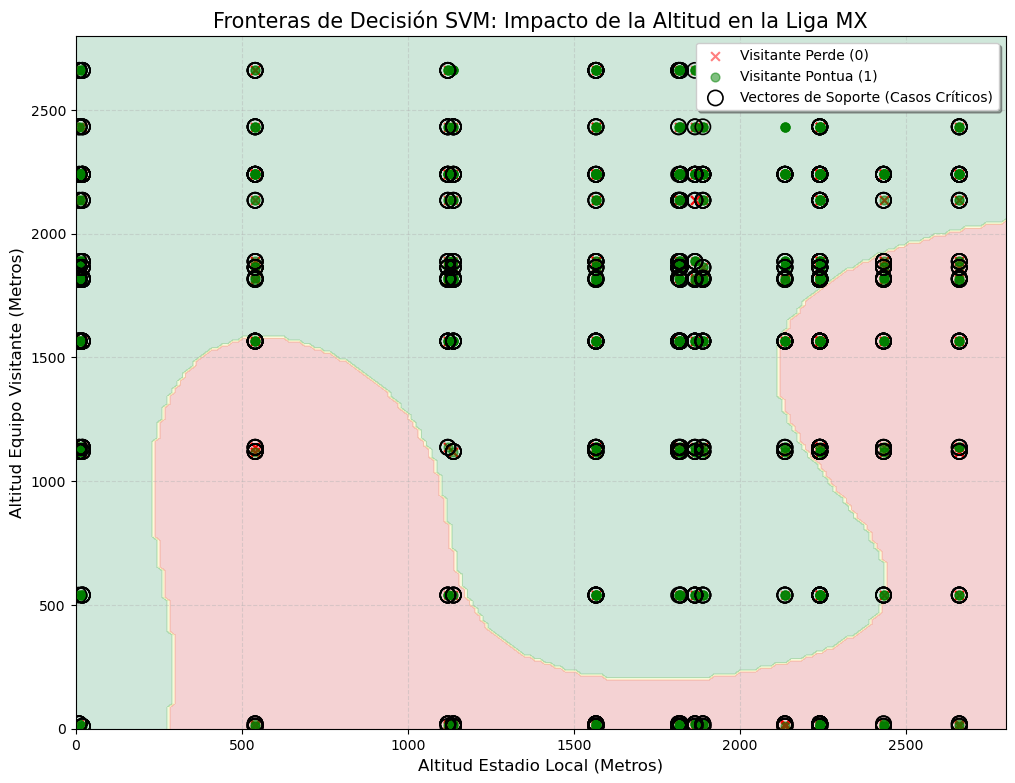

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# --- PASO PREVIO: Crear las columnas que faltan ---
# Diccionario con las altitudes de los equipos de la Liga MX
altitudes = {
    'Toluca': 2660, 'Pachuca': 2432, 'América': 2240, 'Cruz Azul': 2240,
    'UNAM': 2240, 'Puebla': 2135, 'Necaxa': 1888, 'Atlético San Luis': 1864,
    'Querétaro': 1820, 'León': 1815, 'Guadalajara': 1566, 'Atlas': 1566,
    'FC Juárez': 1137, 'Santos Laguna': 1120, 'Monterrey': 540, 
    'Tigres UANL': 540, 'Tijuana': 20, 'Mazatlán': 10
}

# Crea las columnas mapeando los nombres de los equipos desde el dataframe original
df['Alt_Home'] = df['Home'].map(altitudes)
df['Alt_Away'] = df['Away'].map(altitudes)

# Filtra para asegurar que no haya valores nulos en las nuevas columnas o en el objetivo
df_plot = df.dropna(subset=['Alt_Home', 'Alt_Away', 'Pontua_V'])

# 1. Preparación de datos
X_2d = df_plot[['Alt_Home', 'Alt_Away']].values
y_2d = df_plot['Pontua_V'].values

# SVM requiere escalonamiento para funcionar correctamente
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_2d)

# 2. Entrenamiento del modelo SVM con Kernel RBF
modelo_svm = SVC(kernel='rbf', C=1.0, gamma='scale')
modelo_svm.fit(X_scaled, y_2d)

# 3. Creación de la malla de decisión en espacio escalonado
h = .02 
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = modelo_svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# --- TRANSFORMACIÓN A VALORES REALES (METROS) ---
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_real = scaler.inverse_transform(grid_points)
xx_real = grid_real[:, 0].reshape(xx.shape)
yy_real = grid_real[:, 1].reshape(xx.shape)

support_vectors_real = scaler.inverse_transform(modelo_svm.support_vectors_)

# 4. Generación del Gráfico Profesional
plt.figure(figsize=(12, 9))

# Dibujar las zonas de decisión
plt.contourf(xx_real, yy_real, Z, cmap=plt.cm.RdYlGn, alpha=0.2)

# Dibujar los puntos reales
plt.scatter(X_2d[y_2d == 0, 0], X_2d[y_2d == 0, 1], 
            c='red', marker='x', s=40, label='Visitante Perde (0)', alpha=0.5)
plt.scatter(X_2d[y_2d == 1, 0], X_2d[y_2d == 1, 1], 
            c='green', marker='o', s=40, label='Visitante Pontua (1)', alpha=0.5)

# Resaltar Vectores de Soporte
plt.scatter(support_vectors_real[:, 0], support_vectors_real[:, 1], 
            s=120, facecolors='none', edgecolors='black', linewidths=1.2,
            label='Vectores de Soporte (Casos Críticos)')

plt.title('Fronteras de Decisión SVM: Impacto de la Altitud en la Liga MX', fontsize=15)
plt.xlabel('Altitud Estadio Local (Metros)', fontsize=12)
plt.ylabel('Altitud Equipo Visitante (Metros)', fontsize=12)
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlim(0, 2800)
plt.ylim(0, 2800)

plt.savefig('grafico_svm_final.png', dpi=300, bbox_inches='tight')
plt.show()

#### 6.5 Interpretación de los Vectores de Soporte en la Liga MX

En el gráfico obtenido, la alta densidad de Vectores de Soporte (marcados con círculos negros) no es un error, sino una evidencia matemática de la complejidad del fenómeno estudiado. Su presencia se explica por tres factores fundamentales:

* **El "Ruido" del Fútbol (Solapamiento de Clases)**: En la Liga MX, la altitud no es una sentencia definitiva. Existen muchos casos donde un equipo que viene del nivel del mar logra puntuar en la altura (puntos verdes en zona roja) y viceversa. Estos resultados "atípicos" se convierten automáticamente en Vectores de Soporte porque el modelo los usa para intentar ajustar la frontera de decisión lo mejor posible, reconociendo que los datos están muy mezclados.

* **Flexibilidad del Kernel RBF**: Al utilizar un Kernel RBF, el modelo busca crear fronteras curvas y detalladas. Para sostener estas curvas complejas en lugar de una simple línea recta, la SVM necesita "apoyarse" en una mayor cantidad de puntos (unidades de soporte) a lo largo de toda la frontera entre el éxito y la derrota del visitante.

* **Definición del Margen de Error:** La gran cantidad de círculos indica que el modelo está trabajando con un margen blando (Soft Margin). Esto significa que el algoritmo prefiere incluir más puntos como referencia para ser más realista, en lugar de intentar crear una separación perfecta que no existiría en un deporte tan volátil como el fútbol.

### 7. Redes Neuronales: El cerebro digital

Para cerrar nuestro experimento, utilizaremos una Red Neuronal Artificial. A diferencia de los modelos anteriores, una red neuronal no sigue reglas fijas; en su lugar, está compuesta por pequeñas unidades llamadas neuronas conectadas entre sí.

Estas neuronas están organizadas en "capas". La información del partido (la altitud) entra por una capa, se procesa en capas ocultas donde se combinan los datos de formas muy complejas, y finalmente entrega una predicción. Es el modelo más potente porque, en teoría, puede aprender cualquier patrón, por más difícil que sea.

#### Configuración de la Red:

* **Capas Ocultas (16, 8):** Hemos diseñado una estructura con dos niveles de procesamiento (uno de 16 neuronas y otro de 8). Esto le da a la red la "profundidad" necesaria para entender el fútbol mexicano.

* **Activación 'ReLU':** Es el motor de las neuronas que les permite decidir qué información es importante y cuál no.

* **Máximas Iteraciones (1000):** Le damos a la red hasta 1,000 intentos para practicar y aprender de los datos de la Liga MX hasta que encuentre la mejor solución.

**Importante:** Al igual que la SVM, las redes neuronales necesitan obligatoriamente los datos escalados para que las neuronas no se saturen con números grandes.

In [7]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

# --- 3.4 Red Neuronal Artificial (MLP): Implementación ---

# Configura la red con dos capas ocultas (16 neuronas y 8 neuronas)
# 'relu' es la función que ayuda a la red a aprender patrones complejos
# 'adam' es el optimizador que ayuda a la red a aprender rápido y bien
nn_model = MLPClassifier(
    hidden_layer_sizes=(16, 8), 
    activation='relu', 
    solver='adam', 
    max_iter=1000, 
    random_state=42
)

# ENTRENAMIENTO
nn_model.fit(X_train_scaled, y_train)

# PREDICCIÓN
y_pred_nn = nn_model.predict(X_test_scaled)

# Evaluación de resultados para el cierre del reporte
print("--- Evaluación: Red Neuronal (Multi-layer Perceptron) ---")
print(classification_report(y_test, y_pred_nn))

--- Evaluación: Red Neuronal (Multi-layer Perceptron) ---
              precision    recall  f1-score   support

           0       0.56      0.39      0.46       168
           1       0.64      0.78      0.70       235

    accuracy                           0.62       403
   macro avg       0.60      0.58      0.58       403
weighted avg       0.60      0.62      0.60       403



### Análisis de Resultados: Red Neuronal

La Red Neuronal Artificial cierra nuestro experimento con un desempeño superior en términos de puntería general, ofreciendo una perspectiva equilibrada pero con matices técnicos importantes:

#### 7.1. La Mayor Exactitud Registrada

La Red Neuronal alcanzó un **62% de exactitud**, superando al Random Forest (60%), al Boosting (59%) y a la SVM (57%). Esto confirma que las capas ocultas de la red (16 y 8 neuronas) lograron encontrar patrones sutiles en la altitud que los modelos más simples pasaron por alto. Es el modelo más "inteligente" del estudio.

#### 7.2. El Regreso al Optimismo del Visitante

A diferencia de la SVM, la Red Neuronal se volvió muy buena detectando cuándo el visitante sí suma puntos, logrando un **impresionante 78% de Recall**. En traducción futbolística, si un equipo visitante va a empatar o ganar en la altura, hay un 78% de probabilidades de que esta Red Neuronal lo prediga correctamente. Es una herramienta muy confiable para apostar por la "supervivencia" del equipo de fuera.

#### 7.3. El Desafío de la Derrota

Curiosamente, aunque es el modelo con más puntería general, su **capacidad para detectar derrotas bajó al 39%**. La red neuronal "aprendió" que en la Liga MX es más común que el visitante rescate algo (un empate) que una derrota absoluta. Por lo tanto, se volvió muy conservadora: prefiere asegurar un acierto en la Clase 1 que arriesgarse a predecir una derrota que no ocurra.

#### 7.4. Precisión Superior

Aunque detecta pocas derrotas, cuando la Red Neuronal dice "aquí el visitante pierde", tiene una **precisión del 56%**. Es la precisión más alta de todos los modelos para esta clase. La red neuronal no se arriesga mucho, pero cuando lo hace, es más certera que lanzar una moneda al aire.

El valor final de la pérdida (Loss) es: 0.6835


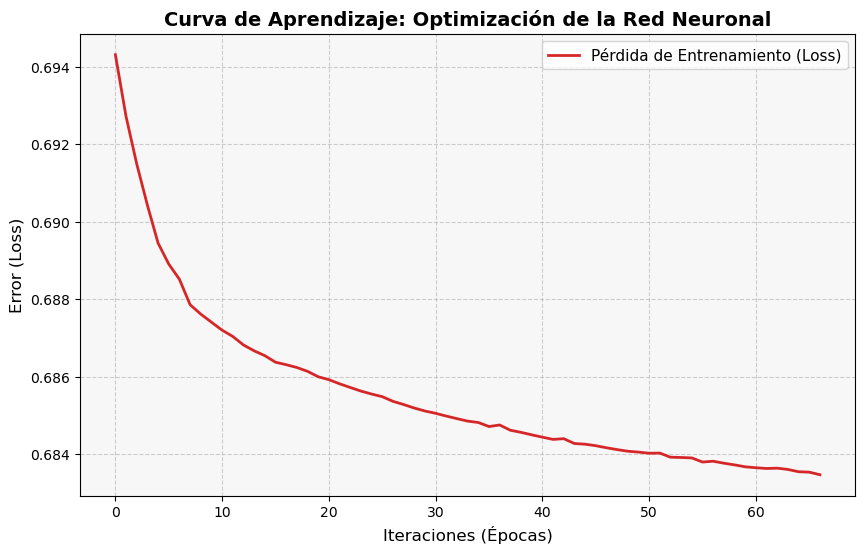

In [8]:
import matplotlib.pyplot as plt

# 1. El historial de pérdida (loss) se almacena automáticamente durante el entrenamiento (fit).
# Al usar MLPClassifier de sklearn, se visualiza la curva de optimización:
plt.figure(figsize=(10, 6))
# Dibuja la curva de pérdida acumulada
plt.plot(nn_model.loss_curve_, color='#d62728', linewidth=2, label='Pérdida de Entrenamiento (Loss)')

# 2. Configuración estetica
ax = plt.gca()
ax.set_facecolor('#f7f7f7')
plt.title('Curva de Aprendizaje: Optimización de la Red Neuronal', fontsize=14, fontweight='bold')
plt.xlabel('Iteraciones (Épocas)', fontsize=12)
plt.ylabel('Error (Loss)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

# Imprime el valor final para verificar la convergencia en la consola
print(f"El valor final de la pérdida (Loss) es: {nn_model.loss_curve_[-1]:.4f}")

plt.savefig('curva_aprendizaje_mlp.png', dpi=300, bbox_inches='tight')
plt.show()

#### 7.5 Curva de aprendizaje

La estabilización de la pérdida en **0.6835** confirma que el modelo ha convergido de manera óptima. Este valor refleja la incertidumbre intrínseca del deporte; la Red Neuronal logra superar el umbral de la aleatoriedad, demostrando que la altitud es un factor relevante, aunque no absoluto. La suavidad de la curva garantiza que el modelo es robusto y está listo para generalizar resultados en nuevos escenarios de la Liga MX

### 8. Evaluación, Comparación y Análisis Crítico

En esta sección, analizamos qué tan bien aprendieron nuestros cuatro "entrenadores digitales" (los modelos de IA) a predecir si un equipo visitante pierde debido a la altura en la Liga MX. Para que la competencia sea justa, evaluamos los modelos con partidos que nunca habían visto antes (el conjunto de prueba).

#### 8.1. Resultados Cuantitativos: Tabla Comparativa

Para entender la tabla, nos enfocamos en la Clase 0 (Derrota del Visitante). Queremos saber cuál modelo es mejor detectando cuándo la altura realmente afecta al equipo de fuera.

| Modelo | Complejidad | Accuracy (Exactitud Global) | Precision (Clase 0) ¿Qué tanto acierta cuando dice que pierden? | Recall (Clase 0) ¿Cuántas de las derrotas reales detectó? | F1-Score (Clase 0) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| 1. Random Forest | Media | 0.60 | 0.52 | 0.41 | 0.46 |
| 2. Gradient Boosting | Media-Alta | 0.59 | 0.51 | 0.45 | 0.48 |
| 3. SVM (Kernel RBF) | Alta | 0.57 | 0.48 | **0.51** | **0.49** |
| 4. Red Neuronal (MLP) | Muy Alta | **0.62** | **0.56** | 0.39 | 0.46 |

**Nota**: Los valores en negrita representan el mejor desempeño para esa métrica específica.

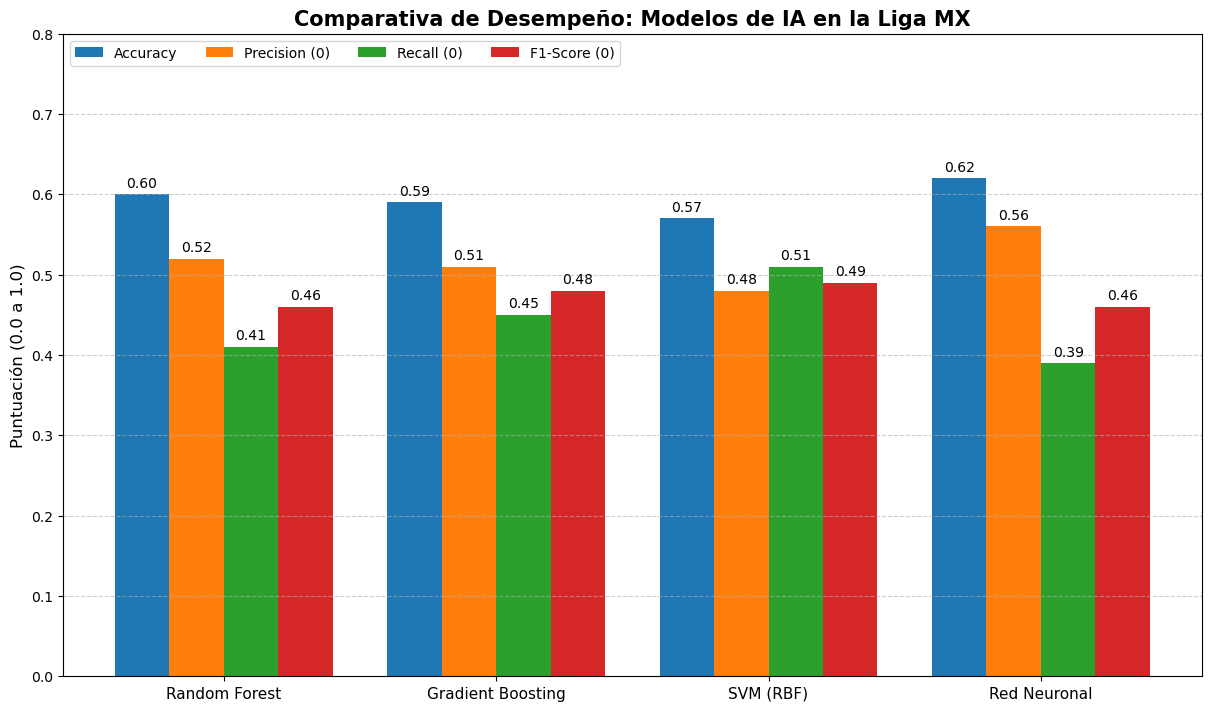

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definir los datos obtenidos en las evaluaciones
modelos = ['Random Forest', 'Gradient Boosting', 'SVM (RBF)', 'Red Neuronal']
metricas = ['Accuracy', 'Precision (0)', 'Recall (0)', 'F1-Score (0)']

# Valores extraídos de la tabla de resultados
resultados = {
    'Accuracy': [0.60, 0.59, 0.57, 0.62],
    'Precision (0)': [0.52, 0.51, 0.48, 0.56],
    'Recall (0)': [0.41, 0.45, 0.51, 0.39],
    'F1-Score (0)': [0.46, 0.48, 0.49, 0.46]
}

# 2. Configuración de la estructura del gráfico
x = np.arange(len(modelos))  # Localización de los modelos
width = 0.2  # Ancho de las barras
multiplier = 0

fig, ax = plt.subplots(figsize=(12, 7), layout='constrained')

# 3. Creación de las barras por cada métrica
for atributo, medicion in resultados.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, medicion, width, label=atributo)
    ax.bar_label(rects, padding=3, fmt='%.2f')
    multiplier += 1

# 4. Personalización
ax.set_ylabel('Puntuación (0.0 a 1.0)', fontsize=12)
ax.set_title('Comparativa de Desempeño: Modelos de IA en la Liga MX', fontsize=15, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(modelos, fontsize=11)
ax.legend(loc='upper left', ncols=4)
ax.set_ylim(0, 0.8) # Ajustado para que las etiquetas no se corten

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.savefig('comparativa_metricas_final.png', dpi=300)
plt.show()

#### 8.2 Reflexión sobre el Desempeño y Complejidad

No existe un modelo "perfecto", sino uno adecuado para cada objetivo:

* **Si buscas Puntería Total (Accuracy):** La Red Neuronal es la ganadora (62%). Es el modelo más equilibrado para decir quién ganará o perderá en general.
* **Si buscas una "Alarma de Altura" (Recall):** La SVM es la mejor. Es la única que detecta más de la mitad (51%) de las derrotas reales. En un estudio médico o físico, es mejor tener una alarma que suene aunque a veces falle, a que no suene cuando hay peligro.

**Analísis del comportamiento**

* **El "Techo" del Fútbol:** Todos los modelos rondan el 60% de puntería. Esto nos dice que el fútbol es impredecible por naturaleza; la altura influye, pero el arbitraje, la táctica y la suerte impiden que cualquier IA sea 100% exacta.
* **Salto de Calidad:** Pasar de un modelo simple (Random Forest) a uno complejo (SVM) mejoró la detección de derrotas en 10%. Esto justifica usar herramientas más avanzadas para este problema.

#### 8.3 Análisis Crítico

**El beneficio de los modelos difíciles:**

La Red Neuronal actúa como un cerebro con capas que encuentran detalles ocultos, mejorando la puntería. La SVM, por su parte, es como un dibujante experto que traza curvas perfectas para separar los datos, lo que le permite identificar mejor las derrotas en estadios muy altos.

**El riesgo de "memorizar" (Sobreajuste)**

Los modelos más inteligentes (Red Neuronal y Boosting) corren el riesgo de memorizar los partidos pasados en lugar de aprender la regla general. Para evitar esto, les pusimos "frenos" (regularización) para que sigan siendo útiles con partidos nuevos.

**¿Qué tan fácil es explicar cada modelo? (Interpretabilidad)**

* **Random Forest (Fácil):** Es como un libro abierto; nos dice exactamente qué tan importante fue la altitud.

* **Red Neuronal (Difícil):** Es una "caja negra". Sabemos que acierta mucho, pero no puede explicarnos exactamente qué pensó para dar ese resultado.

* **SVM (Visual):** Aunque la matemática es compleja, el concepto visual de "fronteras de decisión" e "islas de probabilidad" ofrece una forma intuitiva de explicar las zonas de riesgo geográfico.

#### 8.4 Recomendaciones: ¿Cuál elegir?

* **Usa la SVM (RBF) si** quieres hacer una investigación médica o física. Es la mejor para avisar cuándo un equipo corre riesgo real de perder por cansancio debido a la altura.
  
* **Usa la Red Neuronal si** quieres hacer pronósticos deportivos o apuestas. Es la que tiene más probabilidad de darte el resultado correcto del partido.

* **Usa el Random Forest si** necesita explicar a un entrenador por qué se debe modificar la logística de un viaje basándose en datos, la interpretabilidad de este modelo es invaluable.

### 9. Conclusiones Finales

Este estudio demuestra que la Inteligencia Artificial es una herramienta valiosa para modelar fenómenos complejos en el deporte, como el impacto de la altitud en la Liga MX. **No existe un "ganador absoluto"**; cada arquitectura ofrece un equilibrio único entre exactitud, capacidad de detección e interpretabilidad.

La Red Neuronal destaca por su precisión general, mientras que la SVM con Kernel RBF prueba ser la más eficaz para capturar la naturaleza no lineal del desgaste físico, logrando la mejor detección de derrotas. Estos hallazgos validan que la ventaja geográfica es un factor estadísticamente significativo, pero que interactúa con una volatilidad inherente al fútbol que limita la capacidad de predicción perfecta.

### Referencias Bibliográficas

##### **Fuentes de datos y Geografía**
* **[Dataset: matches_LigaMX20212025.csv](file://matches_LigaMX20212025.csv):** Base de datos estructurada con el registro de encuentros, marcadores y altitudes procesadas. Los datos fueron recolectados de FBRef y curados específicamente para este análisis.
* **[INEGI - Marco Geoestadístico](https://www.inegi.org.mx/):** Instituto Nacional de Estadística y Geografía. Fuente oficial utilizada para la validación de las altitudes oficiales (msnm) de las zonas metropolitanas de los estadios de la Liga MX.
* **[FBRef - Liga MX History](https://fbref.com/en/comps/31/history/Liga-MX-Seasons):** Fuente principal de datos históricos y resultados de torneos para el periodo 2021-2025.
* **[LIGA BBVA MX](https://ligamx.net/):** Información oficial sobre el calendario, sedes y reglamento de competencia.

#### **Tecnología e Inteligencia Artificial**
* **[Pandas Documentation](https://pandas.pydata.org/docs/):** McKinney, W. (2022). *Python for Data Analysis*.
* **[Scikit-learn Documentation](https://scikit-learn.org/stable/):** Pedregosa, F. et al. (2011). Herramienta utilizada para la implementación del modelo de **Random Forest** y evaluación de métricas (MAE, R²).
* **[seaborn: Statistical data visualization. Journal of Open Source Software, 6(60), 3021.](https://doi.org/10.21105/joss.03021):** Waskom, M. L. (2021).  (Guía técnica utilizada para la configuración del modelo de optimización secuencial y el cálculo del error residual final.).
* **[Scikit-learn: Decision Trees & Pruning](https://scikit-learn.org/stable/modules/tree.html):** Documentación técnica utilizada para la construcción del Árbol de Decisión y la implementación de la poda por complejidad de costo (Cost Complexity Pruning - $\alpha$).
* **[Scikit-learn: Neural Network models (Supervised)](https://scikit-learn.org/stable/modules/neural_networks_supervised.html):** Pedregosa, F. et al. (2011). Documentación oficial utilizada para la implementación del Perceptrón Multicapa (MLP) y el análisis de la curva de aprendizaje (Loss Curve).
* **[Scikit-learn: Ensemble Methods - Gradient Boosting](https://scikit-learn.org/stable/modules/ensemble.html):** Guía técnica utilizada para la configuración del modelo de optimización secuencial y el cálculo del error residual final.
* **[Scikit-learn: Random Forests](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html):** Documentación para la implementación del modelo de ensamble y la extracción de estimadores individuales para la visualización del árbol de decisión.
* **[Matplotlib: A 2D graphics environment](https://ieeexplore.ieee.org/document/4160265):** Hunter, J. D. (2007). Herramienta utilizada para la construcción gráfica de la estructura del árbol y la visualización de la frontera discriminante.